# Smart Portfolio Allocation — Results Summary

This notebook presents the final outputs of the Smart Portfolio project.

It does **not** rerun the backtest, bootstrap, or robustness analysis. All results are loaded directly from the CSV files saved in `results/`.

The objective is to summarize the main empirical trade-offs between return, risk, volatility targeting, leverage, turnover, implementation costs, robustness, and statistical uncertainty.

## Base-Case Specification

| Parameter | Value |
|---|---:|
| Allocation estimation window | 3 years |
| Volatility estimation window | 60 trading days |
| Rebalancing frequency | 21 trading days |
| Volatility target | 10% |
| Maximum leverage | 2.0x |
| Transaction cost | 10 bps |
| Annual funding spread | 1% |

The strategy universe contains Equal Weight, Inverse Vol, Max Geo, Max Sharpe, Carver, Hierarchical Inv Vol, SPY, 60/40, and Tech.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path("../results")

In [21]:
# Main results
raw_summary = pd.read_csv(RESULTS_DIR / "raw_summary.csv", index_col=0)
targeted_summary = pd.read_csv(RESULTS_DIR / "targeted_summary.csv", index_col=0)

raw_returns = pd.read_csv(
    RESULTS_DIR / "raw_returns.csv",
    index_col=0,
    parse_dates=True
)
targeted_returns = pd.read_csv(
    RESULTS_DIR / "targeted_returns.csv",
    index_col=0,
    parse_dates=True
)

# Implementation
raw_turnover = pd.read_csv(
    RESULTS_DIR / "raw_turnover_summary.csv",
    index_col=0
)
targeted_turnover = pd.read_csv(
    RESULTS_DIR / "targeted_turnover_summary.csv",
    index_col=0
)

raw_transaction_costs = pd.read_csv(
    RESULTS_DIR / "raw_transaction_cost_summary.csv",
    index_col=0
)
targeted_transaction_costs = pd.read_csv(
    RESULTS_DIR / "targeted_transaction_cost_summary.csv",
    index_col=0
)

targeted_leverage = pd.read_csv(
    RESULTS_DIR / "targeted_leverage_summary.csv",
    index_col=0
)

# Bootstrap
bootstrap_raw = pd.read_csv(
    RESULTS_DIR / "bootstrap_ci_raw.csv",
    index_col=0
)
bootstrap_targeted = pd.read_csv(
    RESULTS_DIR / "bootstrap_ci_targeted.csv",
    index_col=0
)

bootstrap_pairwise_raw = pd.read_csv(
    RESULTS_DIR / "bootstrap_pairwise_raw.csv"
)

bootstrap_pairwise_targeted = pd.read_csv(
    RESULTS_DIR / "bootstrap_pairwise_targeted.csv"
)

# Robustness
robustness_window = pd.read_csv(RESULTS_DIR / "robustness_window.csv")
robustness_vol_window = pd.read_csv(RESULTS_DIR / "robustness_vol_window.csv")
robustness_step = pd.read_csv(RESULTS_DIR / "robustness_step.csv")
robustness_vol_target = pd.read_csv(RESULTS_DIR / "robustness_vol_target.csv")
robustness_leverage = pd.read_csv(RESULTS_DIR / "robustness_leverage.csv")

## 1. Base-Case Performance

Raw portfolios preserve each strategy's natural risk level.

Volatility-targeted portfolios scale exposure toward a 10% annual volatility target, subject to the 2x leverage cap. The reported returns already incorporate the transaction-cost and funding assumptions used in the final backtest.

In [3]:
display(
    raw_summary.style
    .format({
        "Annual Return": "{:.2%}",
        "Annual Volatility": "{:.2%}",
        "Sharpe Ratio": "{:.3f}",
        "Drawdown": "{:.2%}"
    })
    .set_caption("Raw Portfolio Performance")
)

display(
    targeted_summary.style
    .format({
        "Annual Return": "{:.2%}",
        "Annual Volatility": "{:.2%}",
        "Sharpe Ratio": "{:.3f}",
        "Drawdown": "{:.2%}"
    })
    .set_caption("Volatility-Targeted Portfolio Performance")
)

,Annual Return,Annual Volatility,Sharpe Ratio,Drawdown
Equal Weight,7.31%,14.60%,0.459,-41.61%
Inverse Vol,3.77%,4.94%,0.486,-15.47%
Max Geo,11.28%,16.22%,0.653,-39.34%
Max Sharpe,6.56%,9.06%,0.590,-24.99%
Carver,3.17%,3.38%,0.521,-10.07%
Hierarchical Inv Vol,3.33%,3.69%,0.521,-10.25%
SPY,11.40%,19.74%,0.574,-51.48%
60/40,8.28%,11.11%,0.643,-31.48%
Tech,16.43%,22.41%,0.728,-49.37%


,Annual Return,Annual Volatility,Sharpe Ratio,Drawdown
Equal Weight,6.03%,11.28%,0.450,-22.81%
Inverse Vol,4.29%,8.43%,0.372,-24.24%
Max Geo,9.57%,11.73%,0.716,-22.92%
Max Sharpe,6.69%,8.27%,0.653,-22.99%
Carver,3.61%,6.45%,0.362,-20.97%
Hierarchical Inv Vol,3.81%,6.91%,0.370,-21.27%
SPY,8.37%,11.82%,0.619,-21.63%
60/40,8.70%,11.45%,0.661,-20.79%
Tech,9.92%,11.36%,0.765,-18.05%


### Portfolio Growth

Cumulative wealth shows the long-run compounding path of each strategy. Terminal wealth should be interpreted jointly with volatility, drawdowns, leverage, turnover, and statistical uncertainty.

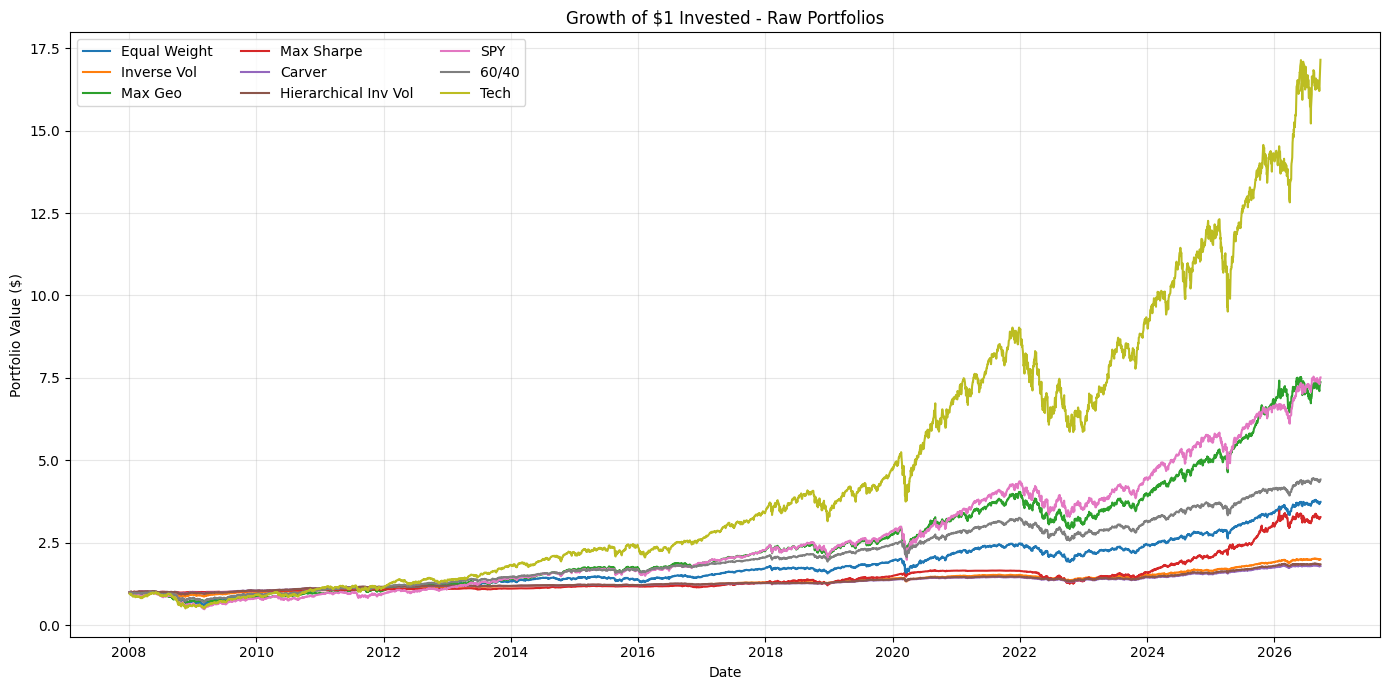

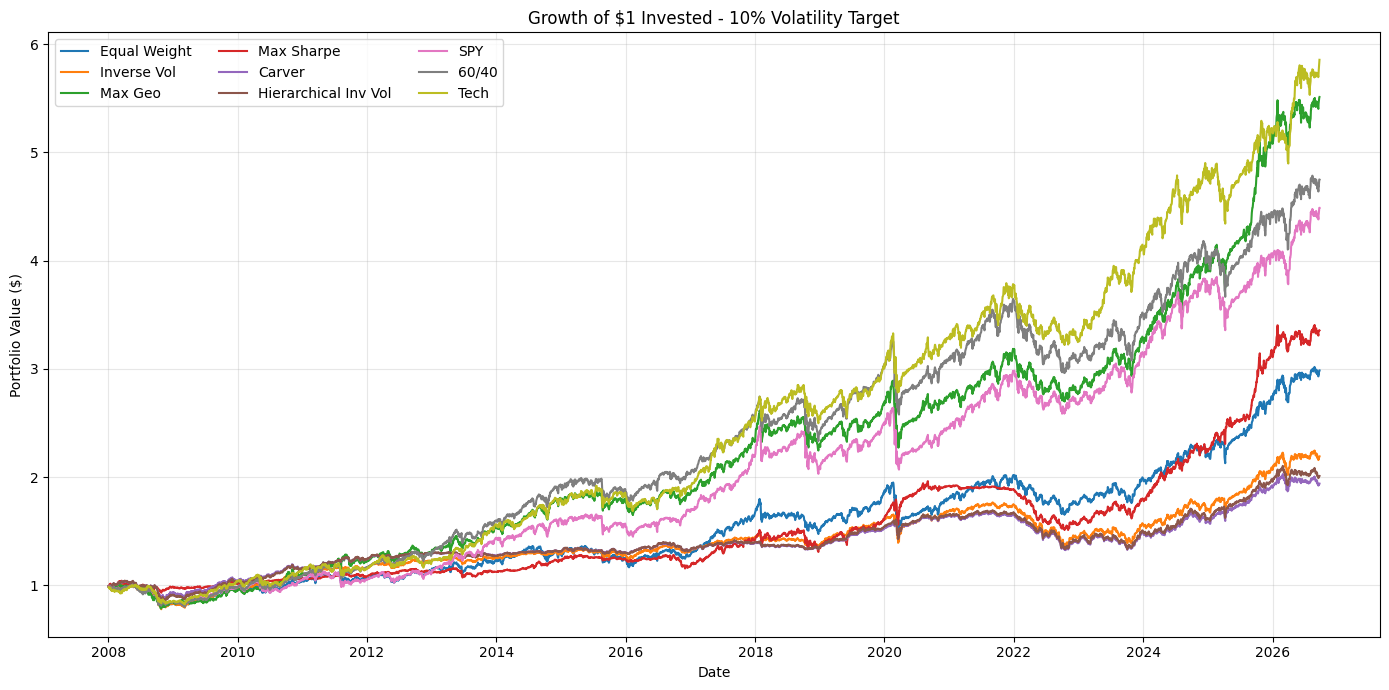

In [4]:
raw_wealth = (1 + raw_returns).cumprod()
targeted_wealth = (1 + targeted_returns).cumprod()

plt.figure(figsize=(14, 7))

for strategy in raw_wealth.columns:
    plt.plot(raw_wealth.index, raw_wealth[strategy], label=strategy)

plt.title("Growth of $1 Invested - Raw Portfolios")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend(ncol=3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 7))

for strategy in targeted_wealth.columns:
    plt.plot(targeted_wealth.index, targeted_wealth[strategy], label=strategy)

plt.title("Growth of $1 Invested - 10% Volatility Target")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend(ncol=3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Risk Profile

The drawdown figure focuses on a representative subset of strategies to keep the comparison readable.

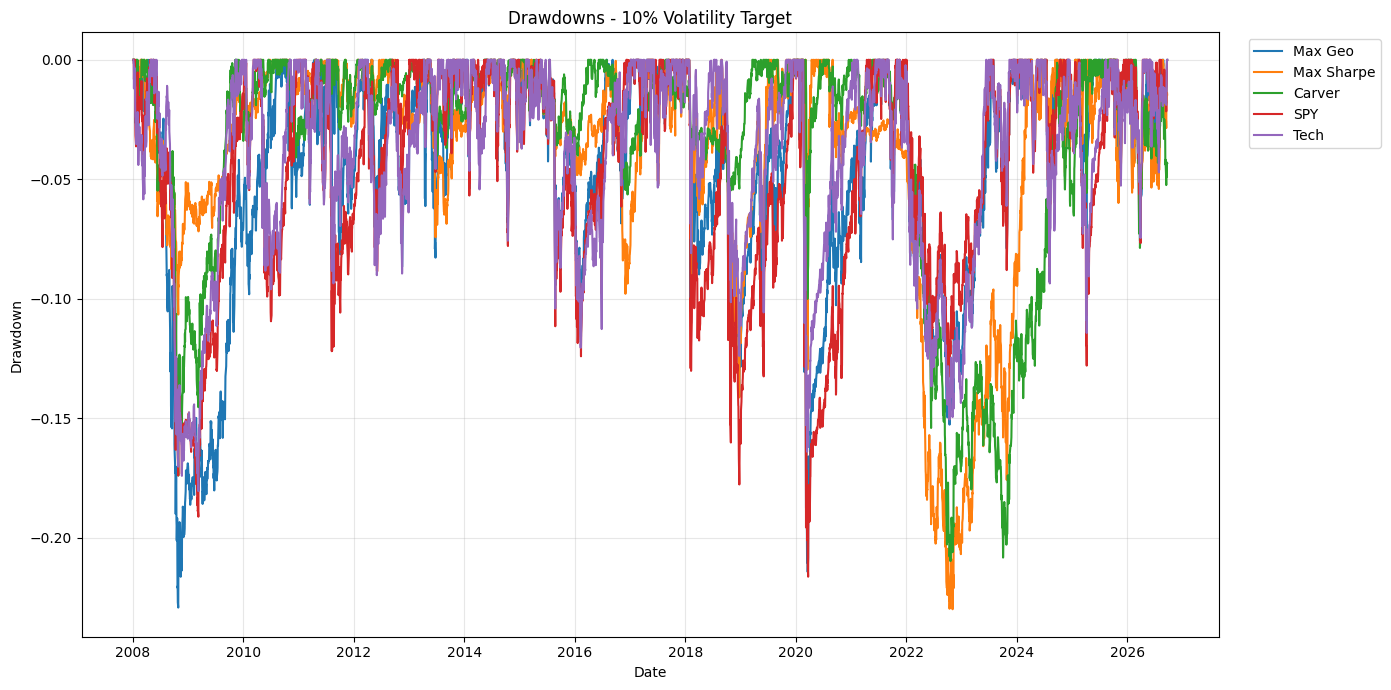

In [5]:
selected = ["Max Geo", "Max Sharpe", "Carver", "SPY", "Tech"]

targeted_drawdown = (
    targeted_wealth[selected]
    / targeted_wealth[selected].cummax()
    - 1
)

plt.figure(figsize=(14, 7))

for strategy in selected:
    plt.plot(
        targeted_drawdown.index,
        targeted_drawdown[strategy],
        label=strategy
    )

plt.title("Drawdowns - 10% Volatility Target")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Leverage Under the 10% Volatility Target

The 10% volatility target dynamically scales each portfolio's exposure according to its estimated risk.

This table shows how much leverage each strategy actually uses under the final base-case specification. A leverage below 1x means that part of the portfolio remains in cash, while leverage above 1x means that the strategy borrows to increase exposure. The maximum leverage is capped at 2x.

The average, minimum, maximum, and proportion of time spent at the 2x cap show how strongly the volatility target changes each strategy's exposure and which strategies frequently reach the leverage limit.

In [10]:
display(
    targeted_leverage.style
    .format({
        "Average Leverage": "{:.2f}x",
        "Max Leverage": "{:.2f}x",
        "Min Leverage": "{:.2f}x",
        "Time at 2x": "{:.2%}"
    })
    .set_caption("Leverage Usage Under the 10% Volatility Target")
)

,Average Leverage,Max Leverage,Min Leverage,Time at 2x
Equal Weight,0.99x,2.00x,0.17x,3.11%
Inverse Vol,1.88x,2.00x,0.58x,73.33%
Max Geo,0.79x,1.70x,0.25x,0.00%
Max Sharpe,1.60x,2.00x,0.36x,63.56%
Carver,1.96x,2.00x,1.02x,88.44%
Hierarchical Inv Vol,1.95x,2.00x,0.91x,87.56%
SPY,0.74x,1.93x,0.13x,0.00%
60/40,1.24x,2.00x,0.23x,9.33%
Tech,0.59x,1.53x,0.15x,0.00%


## 4. Turnover and Transaction Costs

Turnover measures how much portfolio exposure is traded at each rebalance. Higher turnover generally leads to higher transaction costs under the proportional cost model used in the backtest.

The tables below compare trading activity and its associated transaction costs for raw and volatility-targeted portfolios.

`Total Cost` is the cumulative sum of transaction-cost fractions over the full backtest period. It is not an annualized cost and should not be interpreted as a yearly percentage.

In [11]:
raw_implementation = raw_turnover.join(raw_transaction_costs)

display(
    raw_implementation.style
    .format({
        "Average Turnover": "{:.2%}",
        "Max Turnover": "{:.2%}",
        "Total Cost": "{:.2%}",
        "Average Cost per Rebalance": "{:.4%}",
        "Max Cost per Rebalance": "{:.4%}"
    })
    .set_caption("Raw Portfolios — Turnover and Transaction Costs")
)

targeted_implementation = targeted_turnover.join(targeted_transaction_costs)

display(
    targeted_implementation.style
    .format({
        "Average Turnover": "{:.2%}",
        "Max Turnover": "{:.2%}",
        "Total Cost": "{:.2%}",
        "Average Cost per Rebalance": "{:.4%}",
        "Max Cost per Rebalance": "{:.4%}"
    })
    .set_caption("10% Volatility Target — Turnover and Transaction Costs")
)

,Average Turnover,Max Turnover,Total Cost,Average Cost per Rebalance,Max Cost per Rebalance
Equal Weight,1.36%,5.43%,0.61%,0.0027%,0.0109%
Inverse Vol,0.94%,5.60%,0.42%,0.0019%,0.0112%
Max Geo,8.25%,41.38%,3.71%,0.0165%,0.0828%
Max Sharpe,11.70%,85.40%,5.27%,0.0234%,0.1708%
Carver,0.72%,4.81%,0.33%,0.0014%,0.0096%
Hierarchical Inv Vol,0.78%,5.33%,0.35%,0.0016%,0.0107%
SPY,0.00%,0.00%,0.00%,0.0000%,0.0000%
60/40,0.98%,5.39%,0.44%,0.0020%,0.0108%
Tech,0.00%,0.00%,0.00%,0.0000%,0.0000%


,Average Turnover,Max Turnover,Total Cost,Average Cost per Rebalance,Max Cost per Rebalance
Equal Weight,6.53%,60.19%,2.94%,0.0131%,0.1204%
Inverse Vol,4.45%,55.69%,2.00%,0.0089%,0.1114%
Max Geo,10.77%,59.42%,4.85%,0.0215%,0.1188%
Max Sharpe,17.59%,117.48%,7.92%,0.0352%,0.2350%
Carver,2.67%,36.73%,1.20%,0.0053%,0.0735%
Hierarchical Inv Vol,3.06%,44.97%,1.37%,0.0061%,0.0899%
SPY,5.69%,46.27%,2.56%,0.0114%,0.0925%
60/40,8.31%,75.18%,3.74%,0.0166%,0.1504%
Tech,4.25%,24.63%,1.91%,0.0085%,0.0493%


## 5. Robustness

The tables below show how the **Sharpe ratio** changes when key model parameters are varied.

Each row corresponds to a strategy, and each column corresponds to one tested parameter value. The values shown are Sharpe ratios, not returns.

Sharpe is used here as a compact summary of risk-adjusted performance. The full robustness results, including annual return, annual volatility, Sharpe ratio, and drawdown for every scenario, are available in `03_robustness.ipynb` and in the corresponding CSV files saved in `results/`.

Allocation-window and rebalancing-frequency tests are performed on raw portfolios. Volatility-target, leverage-cap, and volatility-estimation-window tests are performed on volatility-targeted portfolios.

In [19]:
def robustness_sharpe_table(df):
    return df.pivot(
        index="Strategy",
        columns="Scenario",
        values="Sharpe Ratio"
    )


tables = [
    (
        "Sharpe Ratio — Allocation Estimation Window",
        robustness_sharpe_table(robustness_window)[["2Y", "3Y", "5Y"]]
    ),
    (
        "Sharpe Ratio — Rebalancing Frequency",
        robustness_sharpe_table(robustness_step)[["Weekly", "Monthly", "Quarterly"]]
    ),
    (
        "Sharpe Ratio — Volatility Target",
        robustness_sharpe_table(robustness_vol_target)[["5%", "10%", "15%"]]
    ),
    (
        "Sharpe Ratio — Maximum Leverage",
        robustness_sharpe_table(robustness_leverage)[["1x", "1.5x", "2x"]]
    ),
    (
        "Sharpe Ratio — Volatility Estimation Window",
        robustness_sharpe_table(robustness_vol_window)[["20D", "60D", "126D", "252D", "756D"]]
    )
]

for caption, table in tables:
    display(
        table.style
        .format("{:.3f}")
        .set_caption(caption)
    )

Scenario,2Y,3Y,5Y
Strategy,,,
60/40,0.841,0.841,0.841
Carver,0.541,0.568,0.555
Equal Weight,0.608,0.608,0.608
Hierarchical Inv Vol,0.557,0.585,0.571
Inverse Vol,0.583,0.622,0.624
Max Geo,0.627,0.811,0.699
Max Sharpe,0.435,0.619,0.600
SPY,0.776,0.776,0.776
Tech,0.878,0.878,0.878


Scenario,Weekly,Monthly,Quarterly
Strategy,,,
60/40,0.635,0.643,0.656
Carver,0.518,0.521,0.516
Equal Weight,0.459,0.459,0.462
Hierarchical Inv Vol,0.517,0.521,0.516
Inverse Vol,0.478,0.486,0.486
Max Geo,0.652,0.653,0.634
Max Sharpe,0.516,0.590,0.551
SPY,0.574,0.574,0.574
Tech,0.728,0.728,0.728


Scenario,5%,10%,15%
Strategy,,,
60/40,0.686,0.661,0.670
Carver,0.410,0.362,0.374
Equal Weight,0.461,0.450,0.439
Hierarchical Inv Vol,0.434,0.370,0.391
Inverse Vol,0.412,0.372,0.385
Max Geo,0.716,0.716,0.698
Max Sharpe,0.655,0.653,0.634
SPY,0.620,0.619,0.611
Tech,0.763,0.765,0.758


Scenario,1x,1.5x,2x
Strategy,,,
60/40,0.703,0.683,0.661
Carver,0.521,0.427,0.362
Equal Weight,0.459,0.451,0.450
Hierarchical Inv Vol,0.522,0.437,0.370
Inverse Vol,0.502,0.419,0.372
Max Geo,0.682,0.712,0.716
Max Sharpe,0.671,0.663,0.653
SPY,0.622,0.616,0.619
Tech,0.751,0.764,0.765


Scenario,20D,60D,126D,252D,756D
Strategy,,,,,
60/40,0.690,0.661,0.611,0.592,0.571
Carver,0.347,0.362,0.366,0.372,0.371
Equal Weight,0.444,0.450,0.406,0.370,0.393
Hierarchical Inv Vol,0.379,0.370,0.371,0.378,0.379
Inverse Vol,0.412,0.372,0.340,0.346,0.329
Max Geo,0.759,0.716,0.687,0.670,0.650
Max Sharpe,0.677,0.653,0.632,0.644,0.648
SPY,0.629,0.619,0.589,0.549,0.507
Tech,0.842,0.765,0.722,0.705,0.683


## 6. Statistical Uncertainty

Sharpe-ratio uncertainty is evaluated with a block bootstrap using 21-trading-day blocks and 10,000 bootstrap samples.

The bootstrap is applied to already aligned portfolio excess returns, avoiding a second risk-free-rate alignment after dates have been resampled.

The tables below report 95% confidence intervals for each strategy's Sharpe ratio. Full bootstrap results, including pairwise Sharpe-difference comparisons and bootstrap samples, are available in `02_bootstrap.ipynb` and in the corresponding CSV files in `results/`.

In [20]:
display(
    bootstrap_raw.style
    .format({
        "CI Lower": "{:.3f}",
        "CI Upper": "{:.3f}"
    })
    .set_caption("Raw Portfolios — 95% Bootstrap Sharpe Confidence Intervals")
)

display(
    bootstrap_targeted.style
    .format({
        "CI Lower": "{:.3f}",
        "CI Upper": "{:.3f}"
    })
    .set_caption("Volatility-Targeted Portfolios — 95% Bootstrap Sharpe Confidence Intervals")
)

,CI Lower,CI Upper
Equal Weight,0.068,0.903
Inverse Vol,0.060,0.961
Max Geo,0.240,1.102
Max Sharpe,0.187,1.009
Carver,0.074,0.984
Hierarchical Inv Vol,0.075,0.987
SPY,0.190,1.023
60/40,0.230,1.114
Tech,0.327,1.185


,CI Lower,CI Upper
Equal Weight,0.033,0.909
Inverse Vol,-0.049,0.850
Max Geo,0.295,1.171
Max Sharpe,0.224,1.086
Carver,-0.088,0.833
Hierarchical Inv Vol,-0.082,0.847
SPY,0.201,1.089
60/40,0.236,1.135
Tech,0.343,1.225


### Pairwise Comparison Against Equal Weight

The tables below compare each strategy's Sharpe ratio with Equal Weight using the bootstrap distributions.

The reported difference is:

**Equal Weight Sharpe − Strategy Sharpe**

A negative value means that the compared strategy has a higher Sharpe ratio than Equal Weight. A positive value means that Equal Weight has a higher Sharpe ratio.

If the 95% confidence interval includes zero, the difference is not clearly distinguished from sampling uncertainty.

Only comparisons against Equal Weight are shown here. Full pairwise results are available in `02_bootstrap.ipynb` and in the corresponding CSV files in `results/`.

In [25]:
raw_vs_equal = bootstrap_pairwise_raw[
    (bootstrap_pairwise_raw["Strategy 1"] == "Equal Weight") |
    (bootstrap_pairwise_raw["Strategy 2"] == "Equal Weight")
].copy()

targeted_vs_equal = bootstrap_pairwise_targeted[
    (bootstrap_pairwise_targeted["Strategy 1"] == "Equal Weight") |
    (bootstrap_pairwise_targeted["Strategy 2"] == "Equal Weight")
].copy()


raw_vs_equal["Strategy"] = raw_vs_equal["Strategy 2"]
targeted_vs_equal["Strategy"] = targeted_vs_equal["Strategy 2"]


raw_vs_equal = (
    raw_vs_equal[
        ["Strategy", "Mean Diff", "CI Lower", "CI Upper"]
    ]
    .set_index("Strategy")
    .rename(columns={"Mean Diff": "Equal Weight - Strategy"})
)

targeted_vs_equal = (
    targeted_vs_equal[
        ["Strategy", "Mean Diff", "CI Lower", "CI Upper"]
    ]
    .set_index("Strategy")
    .rename(columns={"Mean Diff": "Equal Weight - Strategy"})
)


display(
    raw_vs_equal.style
    .format({
        "Equal Weight - Strategy": "{:.3f}",
        "CI Lower": "{:.3f}",
        "CI Upper": "{:.3f}"
    })
    .set_caption("Raw Portfolios — Sharpe Differences vs Equal Weight")
)

display(
    targeted_vs_equal.style
    .format({
        "Equal Weight - Strategy": "{:.3f}",
        "CI Lower": "{:.3f}",
        "CI Upper": "{:.3f}"
    })
    .set_caption("Volatility-Targeted Portfolios — Sharpe Differences vs Equal Weight")
)

,Equal Weight - Strategy,CI Lower,CI Upper
Strategy,,,
Inverse Vol,-0.027,-0.174,0.125
Max Geo,-0.185,-0.434,0.071
Max Sharpe,-0.114,-0.551,0.306
Carver,-0.053,-0.339,0.239
Hierarchical Inv Vol,-0.053,-0.326,0.226
SPY,-0.116,-0.288,0.055
60/40,-0.184,-0.349,-0.021
Tech,-0.268,-0.507,-0.026


,Equal Weight - Strategy,CI Lower,CI Upper
Strategy,,,
Inverse Vol,0.072,-0.135,0.286
Max Geo,-0.260,-0.477,-0.037
Max Sharpe,-0.190,-0.551,0.170
Carver,0.089,-0.250,0.431
Hierarchical Inv Vol,0.080,-0.253,0.417
SPY,-0.171,-0.389,0.046
60/40,-0.216,-0.405,-0.028
Tech,-0.315,-0.582,-0.050


# Conclusion

The results show that no allocation method clearly dominates across all tests.

In the raw portfolios, Tech delivers the highest return at 16.43% but also experiences a drawdown close to 50%. Max Geo reaches 11.28% annual return with a 39.34% maximum drawdown, while lower-volatility methods such as Carver and Hierarchical Inverse Volatility remain below 4% annual volatility but produce much lower returns.

Volatility targeting makes absolute risk levels more comparable, compressing maximum drawdowns to roughly 18%-24% across strategies. However, low-volatility methods require substantial leverage: Carver and Hierarchical Inverse Volatility spend around 88% of the sample at the 2x leverage cap.

Implementation choices also have a large effect on results. Carver's Sharpe falls from 0.521 with a 1x leverage cap to 0.362 at 2x, largely because of funding costs. The volatility-estimation window also matters: SPY's Sharpe is 0.629 with a 20-day estimator, 0.619 with the 60-day base case, and 0.507 with a 756-day estimator.

The allocation robustness tests show that Max Geo and Max Sharpe are more sensitive to the estimation window, with Sharpe changes of about 0.18, compared with about 0.03-0.04 for Carver and Inverse Vol.

Finally, the bootstrap shows substantial statistical uncertainty. Most pairwise Sharpe differences relative to Equal Weight include zero in their 95% confidence intervals. After volatility targeting, Max Geo is one of the few allocation methods whose interval relative to Equal Weight excludes zero, at [-0.477, -0.037]. This result should still be interpreted with some caution because Max Geo is relatively sensitive to the estimation window.

For a more detailed discussion of the methodology, robustness tests and statistical uncertainty, see [analysis.md](../analysis.md).
